[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

### Lecture 5 Time-series
- Autocorrelation
- ACF
- AR(1)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


- load data

In [26]:
df = pd.read_csv("./noaa_roni.csv")

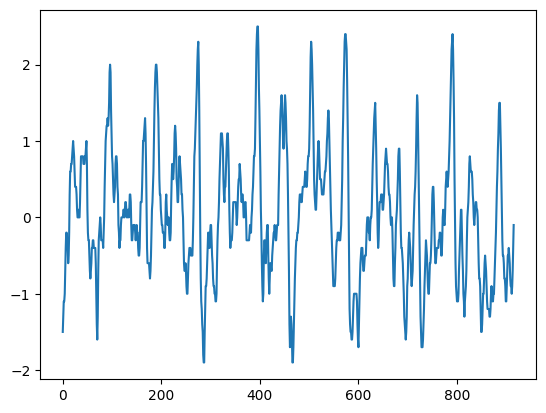

In [27]:
plt.plot(df.RONI)

In [28]:
roni = df["RONI"].values
n = len(roni)
print(n)

916


- using statsmodels to calculate auto-covaraince and ACF


In [29]:
import statsmodels.tsa.stattools as stattools

Text(0, 0.5, 'autocovariance')

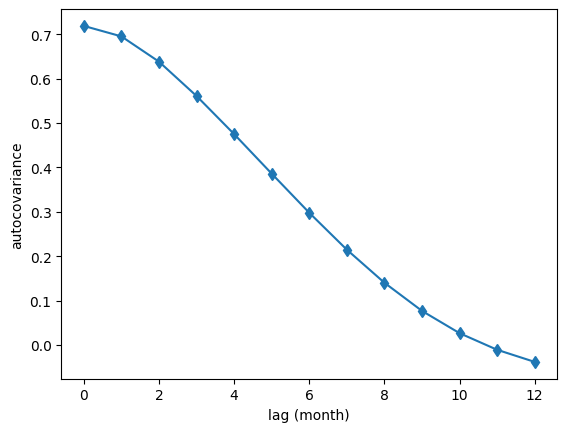

In [30]:
max_lag = 12
c = stattools.acovf(roni, adjusted=False, nlag=max_lag)
plt.plot(np.arange(max_lag+1),c,'d-') # autocovariance
plt.xlabel('lag (month)')
plt.ylabel('autocovariance')

Text(0, 0.5, 'ACF')

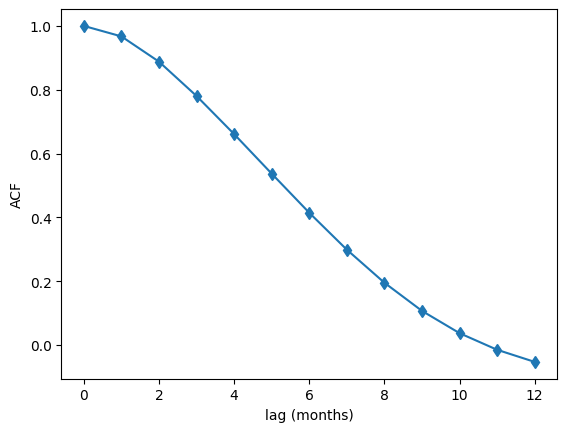

In [31]:
rho   = stattools.acf(roni, nlags=max_lag, adjusted=False)        # normalized ACF
plt.plot(np.arange(max_lag+1),rho,'d-') # autocovariance
plt.xlabel('lag (months)')
plt.ylabel('ACF')

- calculate CI

In [32]:
ci_naive = 1.96 / np.sqrt(n)
ci_naive

np.float64(0.0647602228445988)

In [33]:
# Effective-N CI: n_eff from lag-1 autocorrelation (AR(1)-style closed form)
n_eff = n * (1 - rho[1]) / (1 + rho[1])
ci_neff = 1.96 / np.sqrt(n_eff)
print('n_eff',n_eff)
print('ci_neff', ci_neff)

n_eff 15.285288737874236
ci_neff 0.5013248677209513


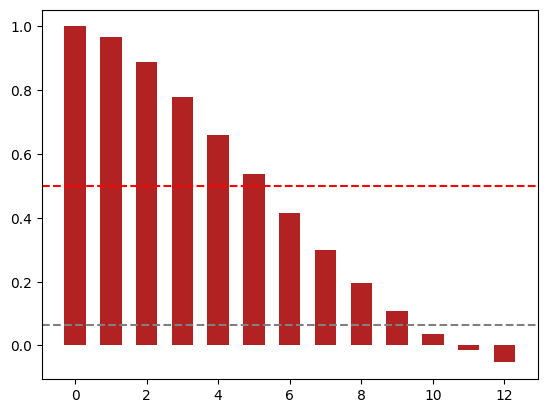

In [34]:
plt.bar(np.arange(0,max_lag+1), rho, width=0.6, color="firebrick", label="Sample ACF (RONI)")
plt.axhline(ci_naive, color="gray", linestyle="--")
plt.axhline(ci_neff , color="r", linestyle="--")

- write a sample auto-correlation function

In [35]:
def sample_autocovariance(x, k):
    n = len(x)
    xbar = np.mean(x)
    xc = x - xbar
    return np.sum(xc[:n - k] * xc[k:]) / n     # divide by n (not n-k)
def sample_acf(x, max_lag):
    gamma0 = sample_autocovariance(x, 0)               # this IS the variance (population, /n)
    return np.array([sample_autocovariance(x, k) / gamma0 for k in range(max_lag + 1)])

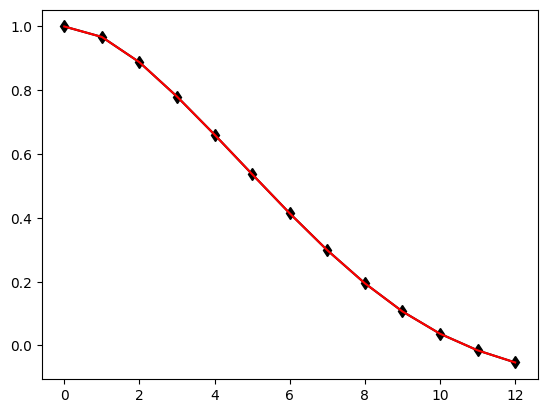

In [36]:
acf_roni = sample_acf(roni, max_lag)
plt.plot(np.arange(max_lag+1),acf_roni,'kd-')
plt.plot(np.arange(max_lag+1),rho,'r-')

-- back to lecture --

- t-test

In [37]:
early = df[(df["Year"] >= 1951) & (df["Year"] <= 1980)]["RONI"].values
recent = df[(df["Year"] >= 1996) & (df["Year"] <= 2025)]["RONI"].values

- get mean and stdanrd deviation

In [38]:
n1, n2 = len(early), len(recent)
mean1, mean2 = early.mean(), recent.mean()
s1, s2 = early.std(ddof=1), recent.std(ddof=1)

-  treats each n as independent

In [39]:
from scipy import stats

t_naive, p_naive = stats.ttest_ind(recent, early, equal_var=False)
print(f"Welch's t-test t = {t_naive:.3f}, p = {p_naive:.4g}")

Welch's t-test t = -5.807, p = 9.678e-09


- considering AR(1)

In [40]:
rho1_early = stattools.acf(early, nlags=1, adjusted=False)[1]
rho1_recent = stattools.acf(recent, nlags=1, adjusted=False)[1]

n_eff1 = n1 * (1 - rho1_early) / (1 + rho1_early)
n_eff2 = n2 * (1 - rho1_recent) / (1 + rho1_recent)
print('ori n', n1, n2)
print('effective n',n_eff1, n_eff2)

ori n 360 360
effective n 7.3031453995894635 6.014748306063649


- calculate corrected t-statistic with corrected standard Errors
$$
SE_{\text{Welch}} = \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}
$$

$$
t = \frac{\bar{x}_2 - \bar{x}_1}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}
$$

In [41]:
se1_corrected = s1 / np.sqrt(n_eff1)
se2_corrected = s2 / np.sqrt(n_eff2)
se_diff_corrected = np.sqrt(se1_corrected**2 + se2_corrected**2)

In [42]:
t_corrected = (mean2 - mean1) / se_diff_corrected
print (t_corrected)

-0.7797101581664039


- now we need to get the p-values, so we need to get Welch's df using effective N

$$
df = \frac{\left(\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}\right)^2}{\dfrac{(s_1^2/n_1)^2}{n_1-1} + \dfrac{(s_2^2/n_2)^2}{n_2-1}}
$$

In [43]:
# Welch-Satterthwaite df using n_eff instead of n
df_corrected = (se1_corrected**2 + se2_corrected**2)**2 / (
    (se1_corrected**2)**2/(n_eff1-1) + (se2_corrected**2)**2/(n_eff2-1)
)


In [44]:
df_corrected

np.float64(9.910511954760743)

- two tails

In [45]:
p_corrected = 2 * (1 - stats.t.cdf(abs(t_corrected), df_corrected))
print('p with effective N',p_corrected)

p with effective N 0.45377912112253593


-- back to lecture --

- Hands on - NYC tmax anomaly

In [46]:
df = pd.read_csv("./nyc_tmax_anomaly_2000_2005.csv", parse_dates=["DATE"])
df

,DATE,TMAX,clim,anomaly
0,2000-01-01,50,41.080889,8.919111
1,2000-01-02,60,40.915590,19.084410
2,2000-01-03,64,40.757790,23.242210
3,2000-01-04,60,40.607635,19.392365
4,2000-01-05,47,40.465266,6.534734
...,...,...,...,...
2187,2005-12-27,43,42.014531,0.985469
2188,2005-12-28,50,41.814038,8.185962
2189,2005-12-29,51,41.620268,9.379732
2190,2005-12-30,47,41.433382,5.566618


### 1st Question
- calculate ACF

- Derive Effective N considering (AR(1))

- Derive $CI = \pm \frac{1.96}{\sqrt{N}}$

### 2nd Question

- conduct 1 sample t- test using stats.ttest_1samp providing the condition population mean is 0
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html

- Derive the critical t: $t = \frac{\bar{x} - 0}{\sigma/\sqrt{n}} $


- get mean and standard deviation of x (i.e., anomaly)
- get t statistic
- get degree of freedom as Neff-1
- get p-values
